# Demo III: a diffusion model learns a Boltzmann distribution

Target: $p(x, y) \propto e^{-U(x,y)/k_BT}$ for a tilted 2D double well.
We draw exact samples, train a small denoising diffusion model (DDPM) on them,
and check what matters to a physicist: **the free-energy profile and the basin populations**.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(4)
t_start = time.time()

BLUE, RED, GREEN, ORANGE, GREY = "#5073B8", "#B85050", "#50B873", "#EBA05A", "#888888"
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

## The physical system and exact samples

In [2]:
kT = 1.0


def U(x, y):
    return 3.0 * (x**2 - 1) ** 2 + 0.6 * x + 1.5 * y**2 + 0.8 * x * y


# exact sampling on a fine grid
xs, ys = np.linspace(-2.2, 2.2, 441), np.linspace(-2.5, 2.5, 501)
GX, GY = np.meshgrid(xs, ys, indexing="ij")
P = np.exp(-U(GX, GY) / kT)
P /= P.sum()
dx, dy = xs[1] - xs[0], ys[1] - ys[0]


def exact_samples(n, rng):
    idx = rng.choice(P.size, size=n, p=P.ravel())
    i, j = np.unravel_index(idx, P.shape)
    return np.stack([xs[i] + dx * (rng.random(n) - 0.5), ys[j] + dy * (rng.random(n) - 0.5)], 1)


rng = np.random.default_rng(0)
data = torch.tensor(exact_samples(50_000, rng), dtype=torch.float32)
p_right_exact = P[xs > 0].sum()
print(f"exact population of the right basin: {p_right_exact:.3f}")

exact population of the right basin: 0.249


## Denoising diffusion: add noise step by step, learn to remove it

In [3]:
T = 400
betas = torch.linspace(1e-4, 0.03, T)
alphas = 1 - betas
abar = torch.cumprod(alphas, 0)


class Denoiser(torch.nn.Module):
    """Predicts the noise eps added to x_t, given x_t and the time step t."""

    def __init__(self, width=128):
        super().__init__()
        self.freqs = torch.arange(1, 9).float()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2 + 16, width), torch.nn.SiLU(),
            torch.nn.Linear(width, width), torch.nn.SiLU(),
            torch.nn.Linear(width, width), torch.nn.SiLU(),
            torch.nn.Linear(width, 2))

    def forward(self, x, t):
        s = (t.float() / T)[:, None] * self.freqs * np.pi
        return self.net(torch.cat([x, torch.sin(s), torch.cos(s)], 1))


def train(steps, seed=0):
    torch.manual_seed(seed)
    model = Denoiser()
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)
    for _ in range(steps):
        x0 = data[torch.randint(len(data), (1024,))]
        t = torch.randint(T, (len(x0),))
        eps = torch.randn_like(x0)
        xt = abar[t].sqrt()[:, None] * x0 + (1 - abar[t]).sqrt()[:, None] * eps
        loss = torch.mean((model(xt, t) - eps) ** 2)
        opt.zero_grad()
        loss.backward()
        opt.step()
        sched.step()
    return model


@torch.no_grad()
def generate(model, n, snapshots=()):
    x = torch.randn(n, 2)
    saved = {T: x.clone()}
    for t in reversed(range(T)):
        tt = torch.full((n,), t)
        eps = model(x, tt)
        x = (x - betas[t] / (1 - abar[t]).sqrt() * eps) / alphas[t].sqrt()
        if t > 0:
            x = x + betas[t].sqrt() * torch.randn_like(x)
        if t in snapshots:
            saved[t] = x.clone()
    return x.numpy(), saved


model = train(steps=6000)
model_short = train(steps=300)             # an under-trained model, for comparison
gen, snaps = generate(model, 50_000, snapshots=(200, 100, 40, 0))
gen_short, _ = generate(model_short, 50_000)
for name, g in [("well trained", gen), ("under-trained", gen_short)]:
    print(f"{name:14s}: right-basin population = {(g[:, 0] > 0).mean():.3f} "
          f"(exact {p_right_exact:.3f})")

well trained  : right-basin population = 0.250 (exact 0.249)
under-trained : right-basin population = 0.250 (exact 0.249)


## From noise to the two basins

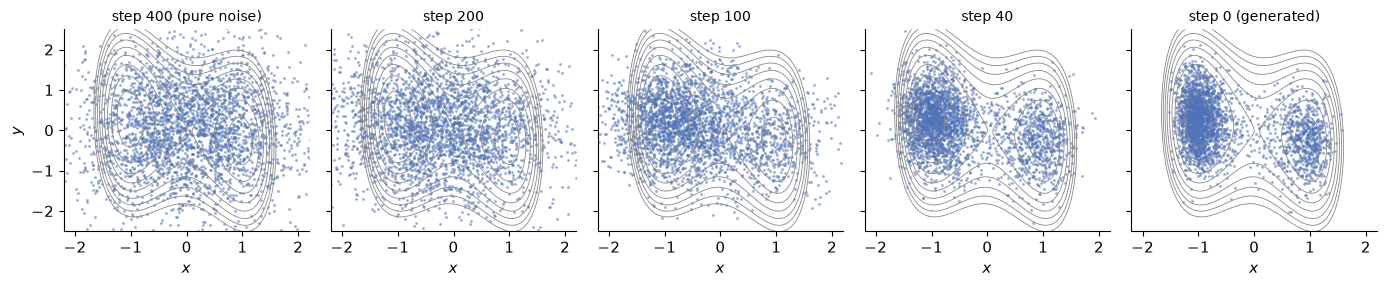

In [4]:
levels = np.arange(-1, 9, 1.0)
fig, axes = plt.subplots(1, 5, figsize=(14, 3.0), sharex=True, sharey=True)
for ax, t in zip(axes, [T, 200, 100, 40, 0]):
    ax.contour(GX, GY, U(GX, GY), levels=levels, colors=GREY, linewidths=0.6)
    pts = snaps[t][:3000].numpy()
    ax.scatter(pts[:, 0], pts[:, 1], s=1.5, alpha=0.4, color=BLUE)
    ax.set_title(f"step {t}" if t else "step 0 (generated)", fontsize=10)
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$y$")
axes[0].set_title(f"step {T} (pure noise)", fontsize=10)
fig.tight_layout()
fig.savefig("figures/fig_III_denoising.pdf")
plt.show()

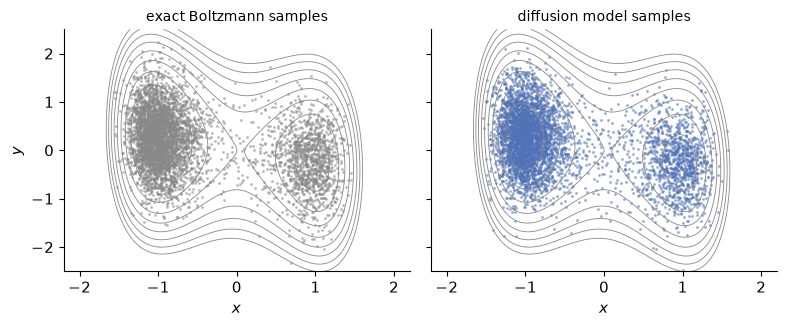

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.4), sharex=True, sharey=True)
for ax, pts, title, c in [(axes[0], data.numpy(), "exact Boltzmann samples", GREY),
                          (axes[1], gen, "diffusion model samples", BLUE)]:
    ax.contour(GX, GY, U(GX, GY), levels=levels, colors=GREY, linewidths=0.6)
    ax.scatter(pts[:5000, 0], pts[:5000, 1], s=1.5, alpha=0.4, color=c)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$y$")
fig.tight_layout()
fig.savefig("figures/fig_III_samples.pdf")
plt.show()

## The physical check: free-energy profile along $x$
$F(x) = -k_BT \ln p(x)$, where $p(x)$ is the marginal over $y$. The barrier region is
exactly where samples are rare.

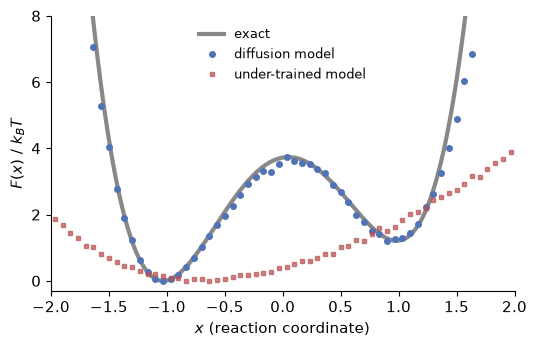

total runtime: 55 s


In [6]:
bins = np.linspace(-2.0, 2.0, 61)
centres = 0.5 * (bins[1:] + bins[:-1])
F_exact = -kT * np.log(P.sum(1) / dx)
F_exact -= F_exact.min()


def free_energy(samples):
    h, _ = np.histogram(samples[:, 0], bins=bins, density=True)
    with np.errstate(divide="ignore"):
        F = -kT * np.log(h)
    return F - np.nanmin(F[np.isfinite(F)])


fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.plot(xs, F_exact, color=GREY, lw=3, label="exact")
ax.plot(centres, free_energy(gen), "o", ms=4, color=BLUE, label="diffusion model")
ax.plot(centres, free_energy(gen_short), "s", ms=3, color=RED, alpha=0.7,
        label="under-trained model")
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-0.3, 8)
ax.set_xlabel("$x$ (reaction coordinate)")
ax.set_ylabel("$F(x)$ / $k_BT$")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig("figures/fig_III_free_energy.pdf")
plt.show()

print(f"total runtime: {time.time() - t_start:.0f} s")